In [826]:

import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt 
from pathlib import Path 
import sys 
import os 
import logging
import seaborn as sns
from decimal import Decimal, ROUND_DOWN
import ast 
import re

from scipy.stats import uniform, randint
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, GroupShuffleSplit
from sklearn.metrics import make_scorer ,root_mean_squared_error

from collections import Counter
from sklearn.preprocessing import FunctionTransformer, StandardScaler

from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.model_selection import GroupKFold,  cross_validate
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectFromModel
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor 
from lightgbm import LGBMRegressor
from sklearn.svm import SVR

from sklearn.compose import TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

from skrub import TableVectorizer


from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, accuracy_score, classification_report, confusion_matrix

sys.path.append('/Users/alina/Desktop/MIT/code/ADHD/MTA/helper')
from helper import rr, prep, var_dict, audit, plot, save


%load_ext autoreload
%autoreload 2

#shap.initjs()

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [827]:
if Path('/Volumes/Samsung_T5/MIT/mta').exists():
    data_root =     '/Volumes/Samsung_T5/MIT/mta'
    data_derived  = '/Volumes/Samsung_T5/MIT/mta/output/derived_data'
else: 
    data_root = '/Users/alina/Desktop/MIT/code/data'
    data_derived  = '/Users/alina/Desktop/MIT/code/data/output/derived_data'

info_path = Path(data_root, "files")
#os.listdir(data_derived)


In [828]:
split_chars = "[0_]"
info_dict = {}
qsts = []

for item in os.listdir(info_path):
    if not item.startswith(".")  and not os.path.isdir(Path(info_path, item)):
        name = re.split(split_chars, item)[0]
        qsts.append(name)
        print(name)
        info_dict[name] = pd.read_csv(Path(info_path, item), usecols=['ElementName','DataType', 'ElementDescription'] )

debrief
debrief14
schoolhx
diagpsx
expect
cisp
health
masc
snap
scapijus
cbcl
pcrc
medse
ssrs
wiat
demgr
scid


In [829]:
################## PREDICTORS ####################
pred = pd.read_csv(Path(data_derived, 'mta_data_clean.csv')).drop(columns = 'Unnamed: 0')
out = pd.read_csv(Path(data_derived, 'out_clean_all_raters.csv')).drop(columns = 'Unnamed: 0')

info = pd.DataFrame()
for key, item in info_dict.items():
    info = pd.concat((info, item))


### get params

In [830]:

file_name_save = 'results_ML_simple_CV_RF_XGB_DOM.csv'
file_path_save = Path(data_derived, 'ML_results', file_name_save)


df_result  = pd.read_csv(Path(data_derived, 'ML_results', file_name_save))

best_result = df_result.loc[df_result['R² Score'] == df_result['R² Score'].max(), :].drop(columns='Unnamed: 0')


params= ast.literal_eval(best_result['Hyperparameters'].iloc[0])
model_type = best_result['Model Name'].iloc[0]
col_out = best_result['Outcome Variable'].iloc[0]
rater_pred = best_result['Input Data'].iloc[0].lower()
corr_select=  best_result['Feature Selection Method'].iloc[0]

if corr_select.startswith('correlation_selector'):
    name_part, dict_part = corr_select.split(' ', 1)
    thr_corr = ast.literal_eval(dict_part)['threshold']

thr_drop_missing = best_result['Threshold Drop Row'].iloc[0]
original_r2 = best_result['R² Score']

col_out_reduced= col_out[:-4]
print(col_out, col_out_reduced, rater_pred)
print(model_type, corr_select)
print(thr_drop_missing, params)

# thr_corr = params['subsample']
# params.pop('subsample', None)


pcrc_pcrcpax_m_out pcrc_pcrcpax_m all
RandomForestRegressor No feature selection
20 {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': None}


In [831]:
best_result

,Model Name,Cross Validation Type,Hyperparameters,Mean Squared Error,Root Mean Squared Error,Mean Absolute Error,R² Score,Outcome Variable,Input Data,Feature Selection Method,Number of Features,Threshold Drop Row
24,RandomForestRegressor,GroupKFold(n_splits=5),"{'n_estimators': 100, 'min_samples_split': 2, ...",0.2104,0.4587,0.3574,0.3105,pcrc_pcrcpax_m_out,all,No feature selection,627,20


In [832]:


 ######################## extract rater pred from pred
if rater_pred is not None:
    col_pred = [ col for col in pred.columns if col.endswith(rater_pred)]
    col_pred.append("src_subject_id")
    col_pred.append('trtname')
    pred = pred[col_pred]
    
    
 ################ OUTCOMES ##################   

out_rater = out[['src_subject_id', col_out_reduced]]
out_rater = out_rater.rename(columns={col: f"{col}_out" for col in out_rater.columns if col != 'src_subject_id'})


################ MERGE ##############
data = pd.merge(out_rater, pred, how = 'left', on = 'src_subject_id')
print(data.keys())
data = audit.remove_cols(data, thr_drop_missing=thr_drop_missing) # adjust if desired, as loaded thr was 50 



Index(['src_subject_id', 'pcrc_pcrcpax_m_out', 'trtname'], dtype='object')
Index([], dtype='object')
Removing empty columns ..  N =  0
Index([], dtype='object')
(559, 3)
Removing constant columns .. N =  0
Index([], dtype='object')
(559, 3)
Removing known and raw columns..  N =  : 0
[]
(559, 3)
Removing above threshold empty columns.. N =  : 0
set()
(559, 3)


In [833]:


y_col = col_out # extrcat single outcome to predict 
print('To predict : ', y_col)

X_cols = [col for col in data.columns if col != y_col]
data = data.dropna(subset=y_col)

y = np.array(data[y_col])
df_X = data[X_cols].drop(columns='src_subject_id')


To predict :  pcrc_pcrcpax_m_out


In [834]:

col_names_data = list(data.columns)

ord_vars, num_vars, cat_vars = [], [], []

types_df = pd.read_excel(Path(data_derived, 'all_vars_description_ML.xlsx'), sheet_name='Sheet1')

for _, row in types_df.iterrows():
    var_name = row[1]  # e.g. variable name in the spreadsheet
    var_type = row[4]  # e.g. "ord" / "num" / "cat"

    # Collect all columns in `data` that contain `var_name`
    var_in_data = [col for col in col_names_data if var_name in col]

    if var_type == "ord":
        ord_vars.append(var_in_data)
    elif var_type == "num":
        num_vars.append(var_in_data)
    elif var_type == "cat":
        cat_vars.append(var_in_data)

# Example: manually add a column named 'trtname' to cat_vars
cat_vars.append(['trtname'])

# Flatten each list-of-lists into a single array
ord_vars = np.concatenate(ord_vars)
cat_vars = np.concatenate(cat_vars)
num_vars = np.concatenate(num_vars)

# Convert them to plain Python strings
ord_vars = [str(col) for col in ord_vars]
cat_vars = [str(col) for col in cat_vars]
num_vars = [str(col) for col in num_vars]

print("Ordinal vars:", ord_vars)
print("Numeric vars:", num_vars)
print("Categorical vars:", cat_vars)

num_vars_in = [str(col) for col in num_vars if not col.endswith("out")] # name of numerical variables present in dataframe X (excludin var names in y)


Ordinal vars: []
Numeric vars: ['pcrc_pcrcpax_m_out']
Categorical vars: ['trtname']


/var/folders/hf/frc4nxb532j7gqr3_36l6kmh0000gn/T/ipykernel_91332/2697639973.py:8: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  var_name = row[1]  # e.g. variable name in the spreadsheet
/var/folders/hf/frc4nxb532j7gqr3_36l6kmh0000gn/T/ipykernel_91332/2697639973.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  var_type = row[4]  # e.g. "ord" / "num" / "cat"


In [835]:
num_set = set(num_vars_in)
ord_set = set(ord_vars)
cat_set = set(cat_vars)

# Pairwise overlaps:
overlap_num_ord = num_set & ord_set
overlap_num_cat = num_set & cat_set
overlap_ord_cat = ord_set & cat_set

print("Overlaps between numeric and ordinal:", overlap_num_ord)
print("Overlaps between numeric and categorical:", overlap_num_cat)
print("Overlaps between ordinal and categorical:", overlap_ord_cat)

# Overlap across all three:
overlap_all_three = num_set & ord_set & cat_set
print("Overlaps across numeric, ordinal and categorical:", overlap_all_three)

Overlaps between numeric and ordinal: set()
Overlaps between numeric and categorical: set()
Overlaps between ordinal and categorical: set()
Overlaps across numeric, ordinal and categorical: set()


In [836]:

cat_vars_str, cat_vars_num, rest = [], [], []

for col in cat_vars:
    # Get the first non-null value in the column
    val = data[col].dropna().unique()[0]
    
    # Check if it's a (Python or NumPy) string
    if isinstance(val, (str, np.str_)):
        cat_vars_str.append(str(col))  # ensure column name is a Python str
    # Check if it's a (Python or NumPy) float
    elif isinstance(val, (float, np.floating)):
        cat_vars_num.append(str(col))  # ensure column name is a Python str
    else:
        rest.append(str(col))          # store in `rest` for debugging
print(cat_vars_str)
print(cat_vars_num)

['trtname']
[]


In [837]:
# Define the extensions to check
extensions = ['_m', #mother 
              #'_p'# proffesionals
              '_f', # father,
              '_c',# child,
              '_t'] # teacher 

# Count columns for each extension
extension_counts = {ext: sum(col.endswith(ext) for col in pred.columns) for ext in extensions}

for ext, count in extension_counts.items():
    print(f"Columns ending with '{ext}': {count}")

Columns ending with '_m': 0
Columns ending with '_f': 0
Columns ending with '_c': 0
Columns ending with '_t': 0


In [838]:
params_train = { 'tune_hyperparam' : False,
          'temp_size' : 0.3, # Size of 
          'test_size' : 0.3,
          'random_state' : 42, 
          'num_top_features': 10, # number of features to keep after featur selection, change to when it doesnt get better anymore 
          'stratify' : 'trtname',
          'gkf_n_splits' : 5} # in balance in train teat split 


scoring = {
    'r2': 'r2',
    'mse': 'neg_mean_squared_error',
    'mae': 'neg_mean_absolute_error'
}

groups = data['src_subject_id'].values

In [839]:
# class CorrelationSelector(BaseEstimator, TransformerMixin):
#     def __init__(self, threshold=0.8):
#         self.threshold = threshold
#         self.to_drop_ = None
#         self.features_to_keep_ = None

#     def fit(self, X, y=None):
#         if not isinstance(X, pd.DataFrame):
#             raise ValueError("CorrelationSelector expects input X to be a pandas DataFrame")
#         corr_matrix = X.corr().abs()
#         upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
#         self.to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
#         self.features_to_keep_ = [col for col in X.columns if col not in self.to_drop_]
#         return self

#     def transform(self, X):
#         return X[self.features_to_keep_]

#     def get_support(self, indices=False):
#         if indices:
#             return [i for i, col in enumerate(self.features_to_keep_)]
#         return self.features_to_keep_

#     def get_feature_names_out(self, input_features=None):
#         return np.array(self.features_to_keep_, dtype=object)

class ToDataFrameTransformer(BaseEstimator, TransformerMixin):
    def __init__(self, preprocessor):
        self.preprocessor = preprocessor
        self.feature_names_ = None

    def fit(self, X, y=None):
        # The preprocessor is already fitted, so we can ask for feature names
        self.feature_names_ = list(self.preprocessor.get_feature_names_out())
        return self

    def transform(self, X):
        # X is a NumPy array, turn it into a DataFrame
        return pd.DataFrame(X, columns=self.feature_names_)

    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_, dtype=object)

In [840]:
df_X.columns.duplicated()

# To list just the duplicated columns:
dup_cols = df_X.columns[df_X.columns.duplicated()]
print("Duplicated column names:", dup_cols.tolist())

Duplicated column names: []


In [841]:
df_X.columns.duplicated()

# To list just the duplicated columns:
dup_cols = df_X.columns[df_X.columns.duplicated()]
print("Duplicated column names:", dup_cols.tolist())
X_select = df_X[list(set(num_vars_in + ord_vars + cat_vars))]
X_select.columns.duplicated()

# To list just the duplicated columns:
dup_cols = X_select.columns[X_select.columns.duplicated()]
print("Duplicated column names:", dup_cols.tolist())

Duplicated column names: []
Duplicated column names: []


In [842]:
# Ensure X is a DataFrame
X = X_select.copy()

# Initialize GroupShuffleSplit for initial train-test split
gss_test = GroupShuffleSplit(n_splits=1, test_size=params_train['test_size'], random_state=params_train['random_state'])
train_val_idx, test_idx = next(gss_test.split(X, y, groups=groups))

# Split data into training-validation and test sets
X_test, y_test, groups_test = X.iloc[test_idx], y[test_idx], groups[test_idx]
X_train_val, y_train_val, groups_train_val = X.iloc[train_val_idx], y[train_val_idx], groups[train_val_idx]

print(f"Total samples: {X.shape[0]}")
print('TRAIN_VAL ', X_train_val.shape, y_train_val.shape)
print('TEST', X_test.shape, y_test.shape)

Total samples: 520
TRAIN_VAL  (364, 1) (364,)
TEST (156, 1) (156,)


In [843]:

# param_distributions_XGB = {
#     'regressor__n_estimators': [100, 300],  # Number of trees in the forest
#     'regressor__max_depth': [None, 10],    # Maximum depth of the trees
#     'regressor__max_features': ['sqrt', 'log2'],  # Number of features to consider at each split
#     'regressor__min_samples_split': [2, 10],  # Minimum samples required to split an internal node
#     'regressor__min_samples_leaf': [1, 4]   # Minimum samples required at a leaf node
# }
# param_distributions_RF = {
#     'regressor__n_estimators': [100, 300],          # Correct prefix
#     'regressor__max_depth': [10, None],
#     'regressor__min_samples_split': [2, 10],
#     'regressor__min_samples_leaf': [1, 4]
# }

In [844]:
param_distributions = { ############# THIS SHOULD BE IN LOOP!!! the code uses standard params now ? 
    f'regressor__{key}':value for key, value in params.items()
}

In [845]:
corr_select

'No feature selection'

In [846]:
type(y)

numpy.ndarray

In [847]:
def root_mean_squared_error(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2))

class NamedFunctionTransformer(FunctionTransformer):
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([], dtype=object)
        return np.array(input_features, dtype=object)

class CorrelationSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8):
        self.threshold = threshold
        self.to_drop_ = None
        self.features_to_keep_ = None
    def fit(self, X, y=None):
        if not isinstance(X, pd.DataFrame):
            raise ValueError("CorrelationSelector expects input X to be a pandas DataFrame")
        corr_matrix = X.corr().abs()
        upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
        self.to_drop_ = [col for col in upper.columns if any(upper[col] > self.threshold)]
        self.features_to_keep_ = [col for col in X.columns if col not in self.to_drop_]
        return self
    def transform(self, X):
        return X[self.features_to_keep_]
    def get_support(self, indices=False):
        if indices:
            return [i for i, col in enumerate(self.features_to_keep_)]
        return self.features_to_keep_
    def get_feature_names_out(self, input_features=None):
        return np.array(self.features_to_keep_, dtype=object)

class NoOpTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return X
    def get_feature_names_out(self, input_features=None):
        if input_features is None:
            return np.array([], dtype=object)
        return np.array(input_features, dtype=object)

class ToDataFrameTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.feature_names_ = None
    def fit(self, X, y=None):
        return self
    def transform(self, X):
        return pd.DataFrame(X, columns=self.feature_names_)
    def set_feature_names(self, names):
        self.feature_names_ = names
    def get_feature_names_out(self, input_features=None):
        return np.array(self.feature_names_, dtype=object)

num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('std_scaler', StandardScaler())
])

ord_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='mean')),
    ('identity', NamedFunctionTransformer(func=lambda x: x))
])

cat_str_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('ohe', OneHotEncoder(handle_unknown="ignore"))
])

cat_num_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=-1)),
    ('ohe', OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ('num', num_pipe, num_vars_in),
    ('cat_str', cat_str_pipe, cat_vars_str),
    ('cat_num', cat_num_pipe, cat_vars_num),
    ('ord', ord_pipe, ord_vars)
])



if model_type == 'XGBRegressor':
    regress = XGBRegressor(random_state=42)
elif model_type == "RF":
    regress = RandomForestRegressor(random_state=43)

to_df = ToDataFrameTransformer()

if corr_select:
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('no_op', NoOpTransformer()), 
        ('regressor', regress)
    ])
else:
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', regress)
    ])

if model_type == "RF":
    param_distributions = {
        'regressor__n_estimators': 100,
        'regressor__max_depth': 10,
        'regressor__min_samples_split': 2,
        'regressor__min_samples_leaf': 1
    }
elif model_type == "XGB":
    param_distributions = {
        'regressor__n_estimators': 100,
        'regressor__max_depth': 10,
        'regressor__colsample_bytree': 0.5,
        'regressor__min_child_weight': 2
    }

pipeline.set_params(**param_distributions)

cv = GroupKFold(n_splits=5)

scorer = {
    'rmse': make_scorer(root_mean_squared_error, greater_is_better=False),
    'mae': make_scorer(mean_absolute_error, greater_is_better=False),
    'r2': make_scorer(r2_score)
}

cv_results = cross_validate(
    pipeline,
    X,
    y,
    groups=groups,
    scoring=scorer,
    cv=cv,
    return_train_score=True
)

pipeline.fit(X, y)

expanded_names = preprocessor.get_feature_names_out()
to_df.set_feature_names(expanded_names)
X_df = to_df.transform(preprocessor.transform(X))

if corr_select:
    corr_selector = CorrelationSelector(threshold=0.8)
    corr_selector.fit(X_df)
    X_final = corr_selector.transform(X_df)
    pipeline.named_steps['regressor'].fit(X_final, y)

print("CV mean RMSE:", -np.mean(cv_results['test_rmse']))
print("CV mean MAE:", -np.mean(cv_results['test_mae']))
print("CV mean R²:", np.mean(cv_results['test_r2']))

final_regressor = pipeline.named_steps['regressor']
importances = final_regressor.feature_importances_

if corr_select:
    feature_names = corr_selector.get_feature_names_out()
else:
    feature_names = expanded_names

for name, imp in zip(feature_names, importances):
    print(name, imp)

/Users/alina/opt/anaconda3/envs/abcd/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:25:27] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/alina/opt/anaconda3/envs/abcd/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:25:27] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/alina/opt/anaconda3/envs/abcd/lib/python3.10/site-packages/xgboost/core.py:158: UserWarning: [13:25:27] WARNING: /var/folders/k1/30mswbxs7r1g6zwn8y4fyt500000gp/T/abs_d9k8pmaj4_/croot/xgboost-split_1724073758172/work/src/learner.cc:740: 
Parameters: { "min_samples_leaf", "min_samples_split" } 

ValueError: Shape of passed values is (520, 1), indices imply (520, 4)

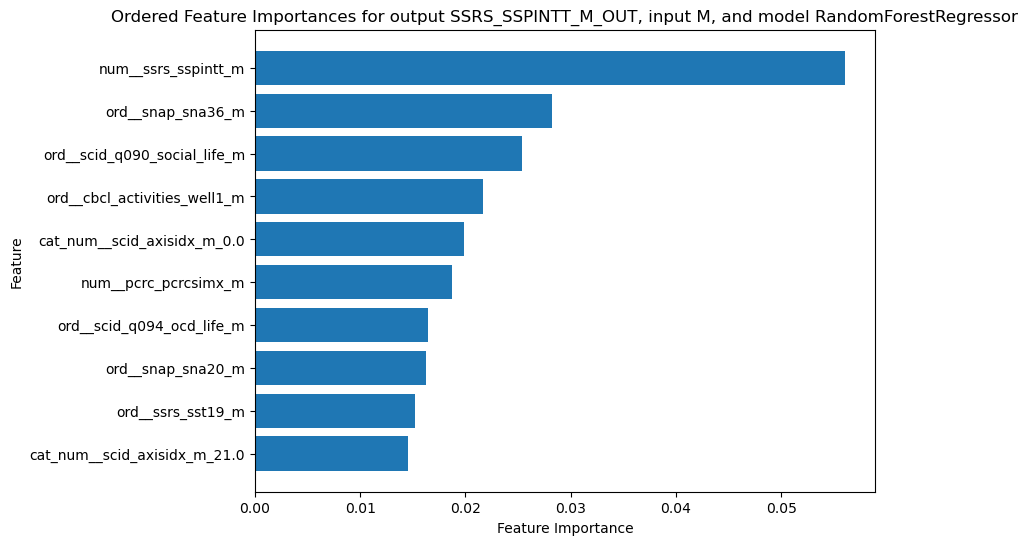

In [ ]:
importances_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 6))
plt.barh(importances_df['feature'][:10], importances_df['importance'][:10])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Ordered Feature Importances for output {}, input {}, and model {}".format(y_col.upper(), rater_pred.upper(), model_type))
plt.show()

In [ ]:
var_description = pd.read_excel(Path(data_derived, 'all_vars_description_ML.xlsx'))

In [ ]:
qsts = ["snap", "ssrs", "masc", "expect", "wiat", ]

In [ ]:
importances_df

,feature,importance
10,num__ssrs_sspintt_m,0.056082
80,ord__snap_sna36_m,0.028215
133,ord__scid_q090_social_life_m,0.025347
139,ord__cbcl_activities_well1_m,0.021654
40,cat_num__scid_axisidx_m_0.0,0.019870
...,...,...
53,cat_num__scid_axisidx_m_30.0,0.000000
50,cat_num__scid_axisidx_m_25.0,0.000000
45,cat_num__scid_axisidx_m_14.0,0.000000
41,cat_num__scid_axisidx_m_1.0,0.000000


In [ ]:
var_description[var_description["ElementName"] == 'sna19']


,Questionnaire,ElementName,ElementDescription,Notes,Type
0,snap,sna19,Stared into space and reported daydreaming,0=Not at all; 1=Just a little; 2=Pretty much; ...,ord


In [ ]:
importances_df

,feature,importance
10,num__ssrs_sspintt_m,0.056082
80,ord__snap_sna36_m,0.028215
133,ord__scid_q090_social_life_m,0.025347
139,ord__cbcl_activities_well1_m,0.021654
40,cat_num__scid_axisidx_m_0.0,0.019870
...,...,...
53,cat_num__scid_axisidx_m_30.0,0.000000
50,cat_num__scid_axisidx_m_25.0,0.000000
45,cat_num__scid_axisidx_m_14.0,0.000000
41,cat_num__scid_axisidx_m_1.0,0.000000


In [ ]:
importances_df['description'] = " "
for i, var in importances_df.iterrows():
    var = importances_df.loc[i, 'feature']
    matches = info[
        info["ElementName"].apply(lambda short_name: short_name in var)
    ]

    if len(matches) >0 :
        importances_df.loc[i, "description"] = matches["ElementDescription"].iloc[0]
    else:
        print(var)

ord__scid_q090_social_life_m
cat_num__scid_axisidx_m_0.0
ord__scid_q094_ocd_life_m
cat_num__scid_axisidx_m_21.0
ord__scid_gadc_m
ord__scid_q085_panic_life_m
ord__scid_q092_phobia_life_m
cat_str__trtname_A
cat_str__trtname_P
ord__scid_q069_sha_life_m
cat_num__scid_axisidx_m_-1.0
ord__scid_othdsml_m
ord__scid_q021_mdd_life_m
ord__scid_q116_bn_life_m
cat_str__trtname_M
cat_num__scid_axisidx_m_22.0
ord__scid_q079_hal_life_m
cat_str__trtname_C
cat_num__scid_axisidx_m_34.0
ord__scid_q071_can_life_m
ord__scid_q067_al_life_m
cat_num__scid_axisidx_m_4.0
ord__scid_q077_coc_life_m
ord__scid_q081_poly_life_m
ord__scid_q073_stim_life_m
cat_num__scid_axisidx_m_33.0
cat_num__scid_axisidx_m_23.0
cat_num__scid_axisidx_m_26.0
cat_num__scid_axisidx_m_3.0
ord__scid_q075_op_life_m
ord__scid_q088_agor_life_m
ord__scid_q114_an_life_m
cat_num__scid_axisidx_m_29.0
ord__scid_q083_othsub_life_m
ord__scid_somatc_m
ord__scid_bpl_m
ord__scid_q018_obp_life_m
cat_num__scid_axisidx_m_24.0
cat_num__scid_axisidx_m_99.0


In [ ]:
(importances_df["importance"] >0).sum()

147

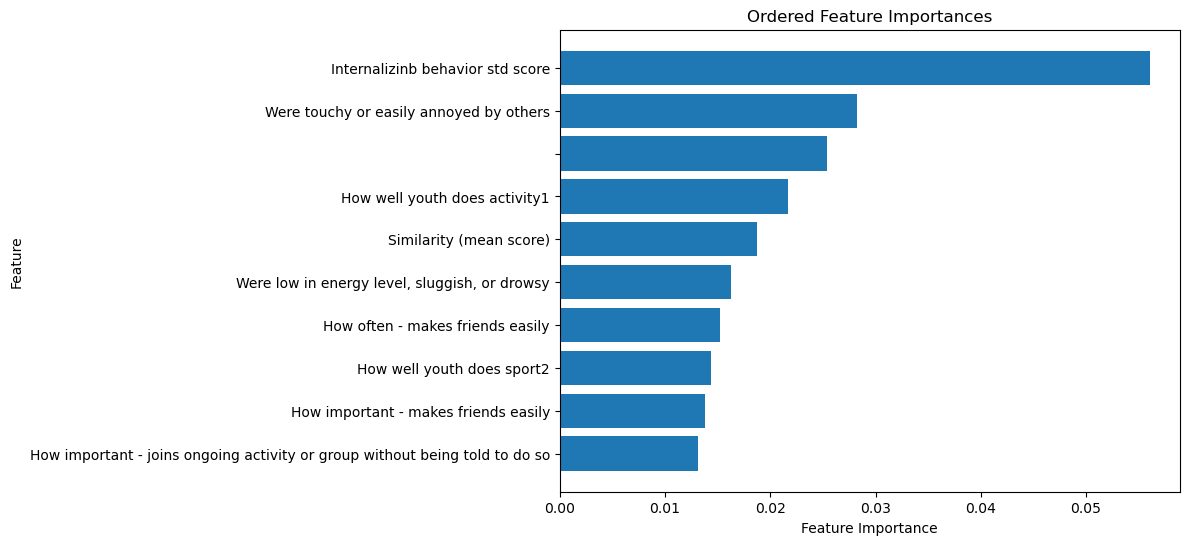

In [ ]:

plt.figure(figsize=(8, 6))
plt.barh(importances_df['description'][:13], importances_df['importance'][:13])
plt.gca().invert_yaxis()
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Ordered Feature Importances")
plt.show()